In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Program parameters
N = 641
NR = 2
h = 100.0 / (N - 1.0)
DKur = 0.5
DKur2 = DKur * DKur
DKur3 = DKur * DKur * DKur
DKur4 = DKur * DKur * DKur * DKur
A_Speed = 1.0
Sigma = 0.5
Omega = (4.0 * DKur2 + 1.0) * (4.0 - DKur2) / 5.0
TimeMax = 50.0

# Allocate arrays
U = np.zeros(N)
U1 = np.zeros(N)
UN = np.zeros(N)
UN1 = np.zeros(N)
U_T = np.zeros(N)
Z = np.zeros(N)
Z1 = np.zeros(N)
X = np.zeros(N)

# Initialize grid
X[0] = 0.0
for i in range(N - 1):
    X[i + 1] = X[i] + h

# Initial condition (Gaussian pulse)
for i in range(N):
    U[i] = np.exp(-(((X[i] - 20.0) / 5.0) * ((X[i] - 20.0) / 5.0)))
    U1[i] = U[i]
    U_T[i] = U[i]

# Time stepping
Time = 0.0
jj = 0

while Time <= TimeMax:
    # Time step calculation
    tau = h * DKur / A_Speed
    Time += tau
    jj += 1
    
    # Boundary conditions
    UL = 0.0
    UR = 0.0
    
    # Rusanov scheme (for U)
    for i in range(2, N - 2):
        UN[i] = U[i] - DKur/12.0 * (-U[i+2] + 8.0*U[i+1] - 8.0*U[i-1] + U[i-2]) \
                + DKur2/8.0 * (U[i+2] - 2.0*U[i] + U[i-2]) \
                - DKur3/12.0 * (U[i+2] - 2.0*U[i+1] + 2.0*U[i-1] - U[i-2]) \
                - Omega/24.0 * (U[i+2] - 4.0*U[i+1] + 6.0*U[i] - 4.0*U[i-1] + U[i-2])
    
    # Author's scheme (for U1)
    for i in range(2, N - 2):
        UN1[i] = Sigma * U1[i] + (1.0 - Sigma) * 0.5 * (U1[i+1] + U1[i-1]) \
                 - 0.5 * DKur * (U1[i+1] - U1[i-1]) \
                 + 0.5 * DKur2 * (U1[i+1] - 2.0 * U1[i] + U1[i-1]) \
                 - 1.0/6.0 * (-(1.0 - Sigma)/4.0 * (U1[i-2] - 16.0*U1[i-1] + 30.0*U1[i] - 16.0*U1[i+1] + U1[i+2]) \
                 + 0.5 * A_Speed * tau / h * (U1[i-2] - 2.0*U1[i-1] + 2.0*U1[i+1] - U1[i+2]) \
                 + 0.25 * A_Speed * A_Speed * tau * tau / h / h * (U1[i-2] - 4.0*U1[i-1] + 6.0*U1[i] - 4.0*U1[i+1] + U1[i+2]))
    
    # Update arrays
    U[:] = UN[:]
    U1[:] = UN1[:]
    
    # Reset temporary arrays
    UN[:] = 0.0
    UN1[:] = 0.0

# Calculate exact solution and errors
for i in range(N):
    U_T[i] = np.exp(-(((X[i] - Time - 20.0) / 5.0) * ((X[i] - Time - 20.0) / 5.0)))
    Z[i] = abs(U[i] - U_T[i])
    Z1[i] = abs(U1[i] - U_T[i])

# Calculate error norms
UMax = np.max(Z)
ULeb = np.sum(Z) * h
ULeb2 = np.sqrt(np.sum(Z**2) * h)

UMax1 = np.max(Z1)
ULeb1 = np.sum(Z1) * h
ULeb12 = np.sqrt(np.sum(Z1**2) * h)

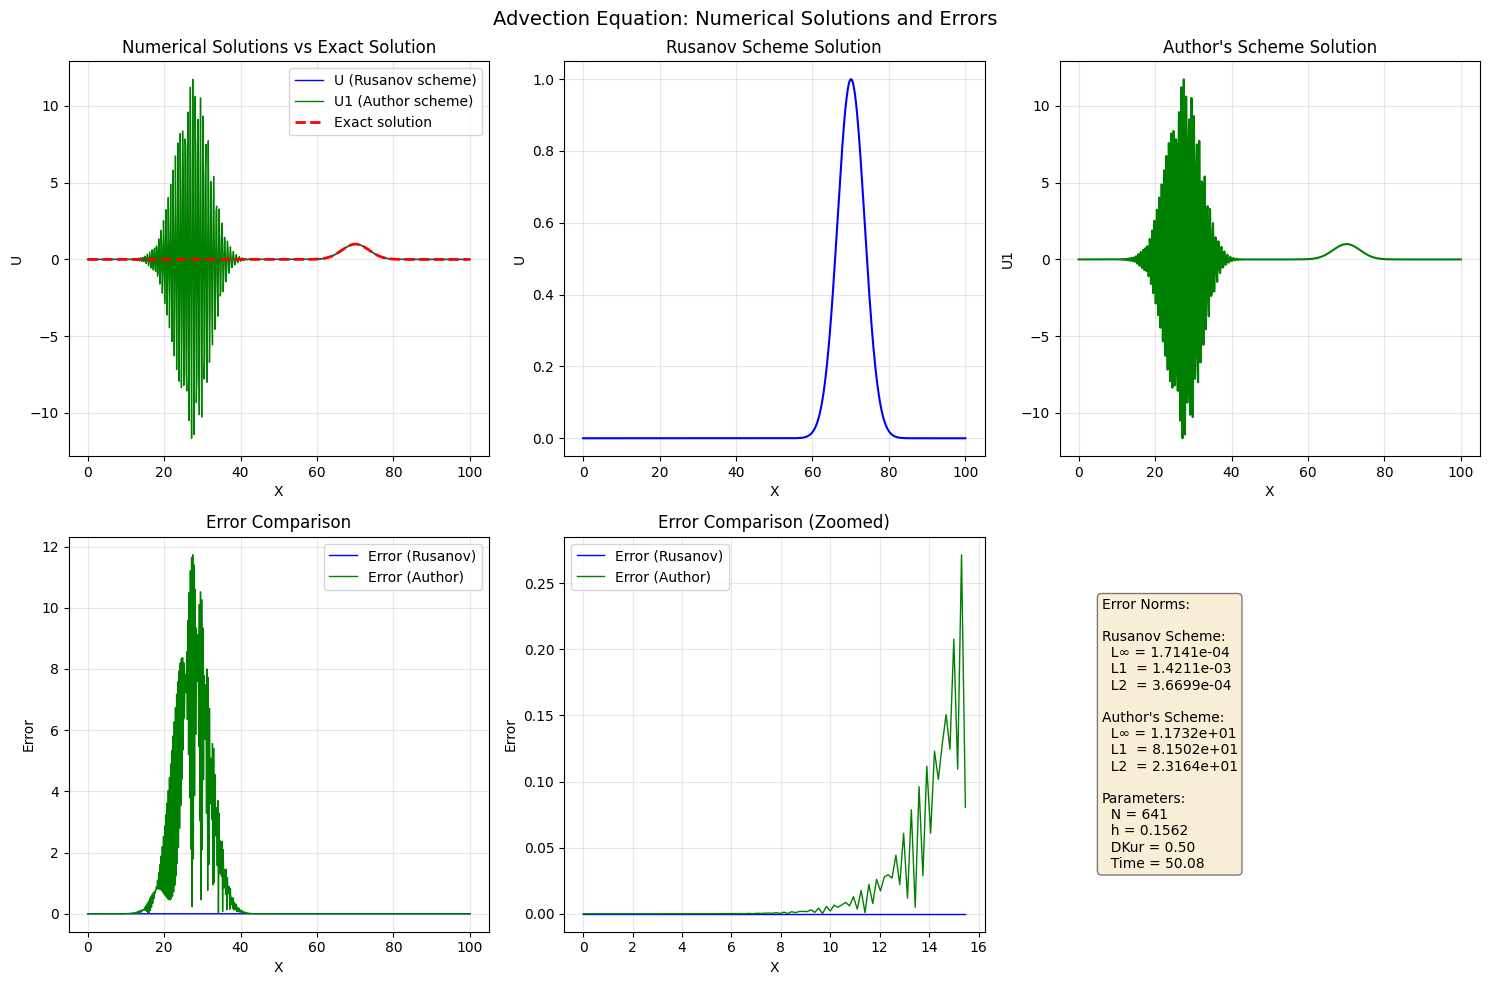

In [7]:

# Create a figure with multiple subplots
plt.figure(figsize=(15, 10))

# Plot 1: Numerical solutions and exact solution
plt.subplot(2, 3, 1)
plt.plot(X, U, 'b-', linewidth=1, label='U (Rusanov scheme)')
plt.plot(X, U1, 'g-', linewidth=1, label='U1 (Author scheme)')
plt.plot(X, U_T, 'r--', linewidth=2, label='Exact solution')
plt.xlabel('X')
plt.ylabel('U')
plt.title('Numerical Solutions vs Exact Solution')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Rusanov scheme solution
plt.subplot(2, 3, 2)
plt.plot(X, U, 'b-', linewidth=1.5)
plt.xlabel('X')
plt.ylabel('U')
plt.title('Rusanov Scheme Solution')
plt.grid(True, alpha=0.3)

# Plot 3: Author's scheme solution
plt.subplot(2, 3, 3)
plt.plot(X, U1, 'g-', linewidth=1.5)
plt.xlabel('X')
plt.ylabel('U1')
plt.title("Author's Scheme Solution")
plt.grid(True, alpha=0.3)

# Plot 4: Error comparison
plt.subplot(2, 3, 4)
plt.plot(X, Z, 'b-', linewidth=1, label='Error (Rusanov)')
plt.plot(X, Z1, 'g-', linewidth=1, label='Error (Author)')
plt.xlabel('X')
plt.ylabel('Error')
plt.title('Error Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 5: Zoomed error comparison (first 100 points)
plt.subplot(2, 3, 5)
plt.plot(X[:100], Z[:100], 'b-', linewidth=1, label='Error (Rusanov)')
plt.plot(X[:100], Z1[:100], 'g-', linewidth=1, label='Error (Author)')
plt.xlabel('X')
plt.ylabel('Error')
plt.title('Error Comparison (Zoomed)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 6: Error norms text display
plt.subplot(2, 3, 6)
plt.axis('off')
textstr = '\n'.join((
    f'Error Norms:',
    f'',
    f'Rusanov Scheme:',
    f'  L∞ = {UMax:.4e}',
    f'  L1  = {ULeb:.4e}',
    f'  L2  = {ULeb2:.4e}',
    f'',
    f"Author's Scheme:",
    f'  L∞ = {UMax1:.4e}',
    f'  L1  = {ULeb1:.4e}',
    f'  L2  = {ULeb12:.4e}',
    f'',
    f'Parameters:',
    f'  N = {N}',
    f'  h = {h:.4f}',
    f'  DKur = {DKur:.2f}',
    f'  Time = {Time:.2f}'
))
plt.text(0.1, 0.5, textstr, fontsize=10, verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle(f'Advection Equation: Numerical Solutions and Errors', fontsize=14)
plt.tight_layout()
plt.show()

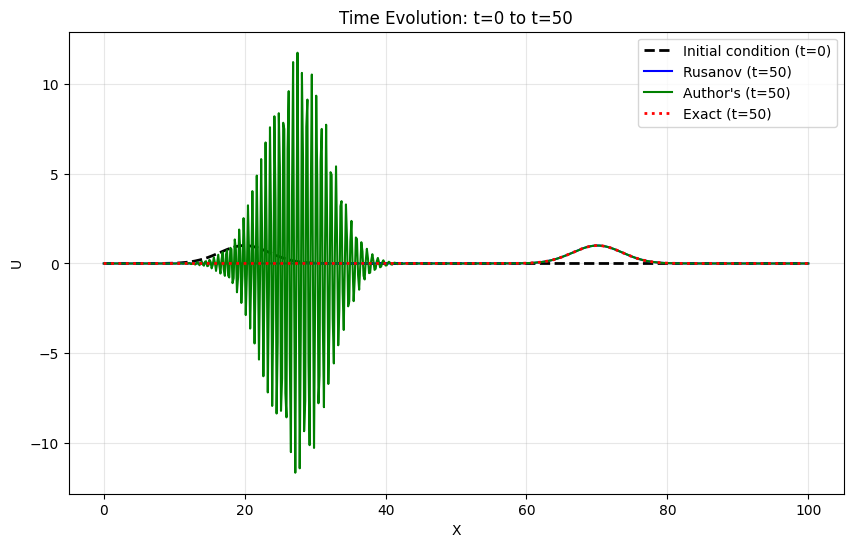

ERROR SUMMARY

Rusanov Scheme Errors:
  L∞ (max) error: 1.7141e-04
  L1 error:       1.4211e-03
  L2 error:       3.6699e-04

Author's Scheme Errors:
  L∞ (max) error: 1.1732e+01
  L1 error:       8.1502e+01
  L2 error:       2.3164e+01

Scheme Comparison (Rusanov/Author):
  L∞ ratio: 0.0000
  L1 ratio:  0.0000
  L2 ratio:  0.0000

Parameters:
  Grid points: N = 641
  Spatial step: h = 0.156250
  CFL number: DKur = 0.50
  Final time: Time = 50.08


In [8]:

# Additional plot: Initial vs Final solutions
plt.figure(figsize=(10, 6))

# Recalculate initial condition for comparison
U_initial = np.exp(-(((X - 20.0) / 5.0) ** 2))

plt.plot(X, U_initial, 'k--', linewidth=2, label='Initial condition (t=0)')
plt.plot(X, U, 'b-', linewidth=1.5, label='Rusanov (t=50)')
plt.plot(X, U1, 'g-', linewidth=1.5, label="Author's (t=50)")
plt.plot(X, U_T, 'r:', linewidth=2, label='Exact (t=50)')
plt.xlabel('X')
plt.ylabel('U')
plt.title('Time Evolution: t=0 to t=50')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print error summary to console
print("=" * 60)
print("ERROR SUMMARY")
print("=" * 60)
print(f"\nRusanov Scheme Errors:")
print(f"  L∞ (max) error: {UMax:.4e}")
print(f"  L1 error:       {ULeb:.4e}")
print(f"  L2 error:       {ULeb2:.4e}")

print(f"\nAuthor's Scheme Errors:")
print(f"  L∞ (max) error: {UMax1:.4e}")
print(f"  L1 error:       {ULeb1:.4e}")
print(f"  L2 error:       {ULeb12:.4e}")

print(f"\nScheme Comparison (Rusanov/Author):")
print(f"  L∞ ratio: {UMax/UMax1:.4f}")
print(f"  L1 ratio:  {ULeb/ULeb1:.4f}")
print(f"  L2 ratio:  {ULeb2/ULeb12:.4f}")

print(f"\nParameters:")
print(f"  Grid points: N = {N}")
print(f"  Spatial step: h = {h:.6f}")
print(f"  CFL number: DKur = {DKur:.2f}")
print(f"  Final time: Time = {Time:.2f}")
print("=" * 60)